<a href="https://colab.research.google.com/github/AnaCarol21/desafio_nps_fase_1/blob/main/desafio_nps_fase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1 Tech challenge de NPS

## Parte 1 </br> Entendimento do negócio: nessa primeira etapa, queremos exercitar o seu pensamento analítico, não código. Nos traga a resposta para as seguintes perguntas de negócio:

## Qual problema de negócio está sendo resolvido?
A coleta tardia do NPS impede a identificação precoce de uma má experiência, impossibilitando a atuação em tempo real. Isso impacta negativamente a experiência do cliente, refletindo em menores taxas de conversão e recompra.

## Por que o NPS é importante para um e-commerce?
O NPS é de suma importância para o e-commerce. Por meio desse indicador que medimos o grau de satisfação após a jornada de compra do cliente. Com isso, conseguimos identificar falhas e oportunidades de melhorias, impactando diretamente na retenção, recompra e  crescimento do negócio.

## Quais áreas poderiam se beneficiar desses insights?
Os insights obtidos a partir do NPS podem beneficiar diversas áreas do e-commerce, como:
- Logística: identificação de problemas relacionados a prazo, rastreio e qualidade na entrega.
- Atendimento ao cliente: análise de reclamações e principais pontos de insatisfação, permitindo melhorias no suporte e redução de demandas.
- Plataforma: identificação de falhas técnicas, dificuldades de navegação, possibilitando melhorias na experiência de compra.

Quanto mais satisfeito o cliente está com a sua compra, maiores são as chances de recompra e de recomendação para outras pessoas. Além disso, uma melhor experiência e maior nível de satisfação contribuem para o aumento da retenção de clientes e fortalecem a competitividade da empresa, podendo influenciar positivamente seu market share em relação aos concorrentes.

#Parte 2 </br> Definição da Target: qual é o alvo desse problema de negócio? Nessa segunda etapa queremos uma avaliação de entendimento conceitual, não técnico.

##Qual variável representa a satisfação do cliente?
nps_score
##Por que ela foi escolhida?
Foi escolhida por representar o valor de nota que o cliente deixou após completar sua experiência de compra.
##Em que momento da jornada essa informação é coletada?
Após completar a jornada de entrega, quando o cliente já passou pela experiência completa do e-commerce
##Existe algum risco de usar essa variável de forma inadequada?
Sim, existe risco ao analisar essa variável de forma isolada, sem considerar outros indicadores ao longo da jornada. Por ser coletado apenas após a conclusão da compra, há perda de informações de clientes que não finalizaram o processo, o que pode gerar uma visão limitada da experiência.

# Parte 3 - Análise Exploratória dos Dados (EDA): realize uma análise exploratória com foco em negócio, não só estatística.


In [3]:
# Importações
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Carregando dados
df_nps = pd.read_csv("desafio_nps_fase_1.csv")

In [5]:
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [6]:
df_nps.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [7]:
# Base de dados não apresenta nenhum dado nulo
df_nps.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [8]:
# Classificando com os nomes de Detrator entre 0 a 6, Neutro de 7 a 8 e superior ou igual a 9 Promotor
def classificar_nps(score):
    if score < 7:
        return "Detrator"
    elif score < 9:
        return "Neutro"
    else:
        return "Promotor"

df_nps["nps_group"] = df_nps["nps_score"].apply(classificar_nps)

In [9]:
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_group
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Detrator
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Detrator


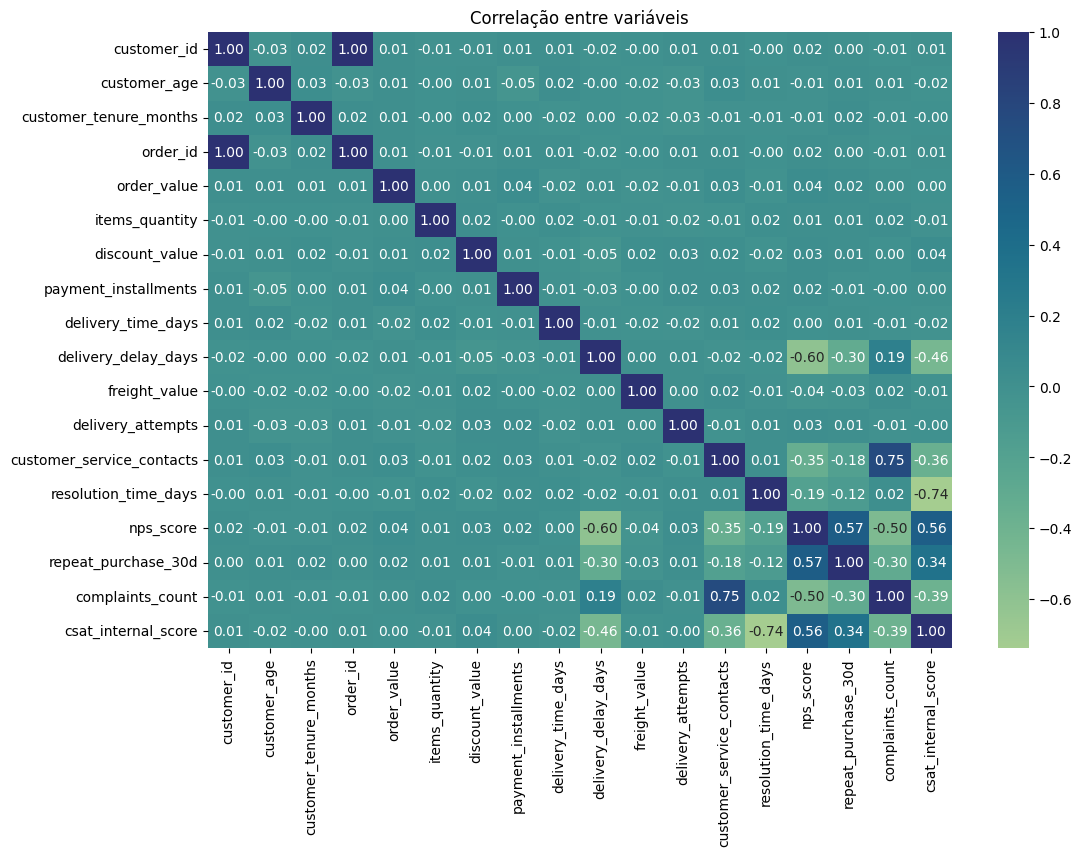

In [11]:
# Criando um gráfico de correlação para começarmos a começar a identificar indicadores de insatisfação
corr = df_nps.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="crest", fmt=".2f")
plt.title("Correlação entre variáveis")
plt.show()

##Quais fatores parecem mais críticos para a satisfação?
A análise de correlação indica que variáveis como atraso na entrega (delivery_delay_days), número de contatos com o atendimento (customer_service_contacts) e quantidade de reclamações (complaints_count) apresentam forte correlação negativa com o NPS, sugerindo que falhas na logística e no suporte ao cliente são os principais fatores de insatisfação.

Variáveis como recompra em até 30 dias (repeat_purchase_30d) e o score interno de satisfação (csat_internal_score) apresentam correlação positiva com o NPS, indicando que uma boa experiência do cliente está associada à fidelização e maior propensão à recompra.


In [30]:
df_nps.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


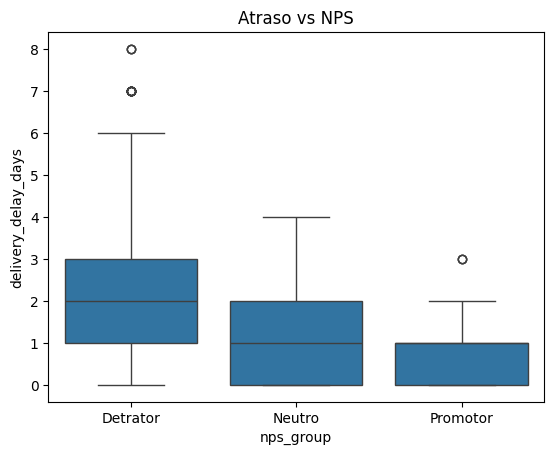

In [24]:
sns.boxplot(x="nps_group", y="delivery_delay_days", data=df_nps)
plt.title("Atraso vs NPS")
plt.show()

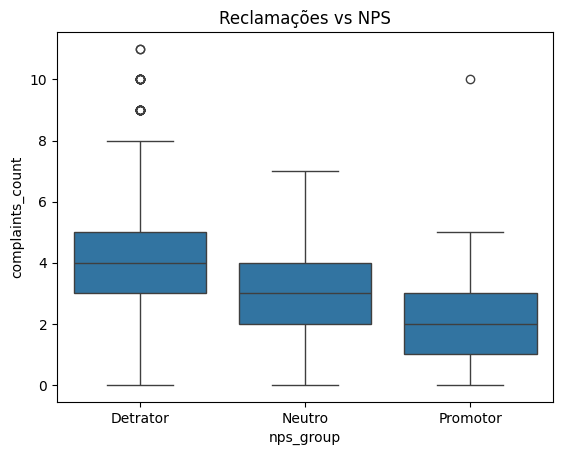

In [26]:
sns.boxplot(x="nps_group", y="complaints_count", data=df_nps)
plt.title("Reclamações vs NPS")
plt.show()

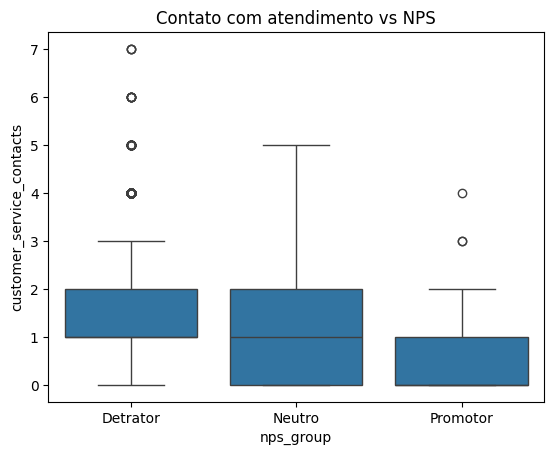

In [27]:
sns.boxplot(x="nps_group", y="customer_service_contacts", data=df_nps)
plt.title("Contato com atendimento vs NPS")
plt.show()

##O que mais gera detratores?
Os gráficos mostram que a maior concentração de clientes detratores estão relacionados à área de logística e também com o atendimento. Resultados sugerem que a insatisfação não está associada a um único fator, mas sim a um amontoado de problemas ao longo da jornada de compra. Melhorias na logística e resolução rápida dos problemas de suporte estão ligadas a melhoria no NPS

In [21]:
df_nps.groupby("delivery_delay_days")["nps_score"].mean()

,nps_score
delivery_delay_days,
0,6.856679
1,5.546179
2,4.580186
3,3.436762
4,2.444444
5,1.481034
6,1.097059
7,0.292857
8,0.000000


##Existe algum “ponto de ruptura” na experiência do cliente?
Após conferir a média de nps com base no tempo de atraso nota-se que a partir de 2 dias de atraso há uma queda considerável na nota do NPS. Indicando um possível ponto de ruptura. Dessa forma, aumenta a tendência de clientes que entrarão em contato e aumentando o número de reclamações. Reforçando a ideia de que a partir de problemas logísticos impactam negativamente a jornada de compra.

In [40]:
# Tempo médio de relacionamento do cliente com a empresa por categoria
df_nps.groupby("nps_group")["customer_tenure_months"].mean()

,customer_tenure_months
nps_group,
Detrator,61.433381
Neutro,59.832740
Promotor,63.000000


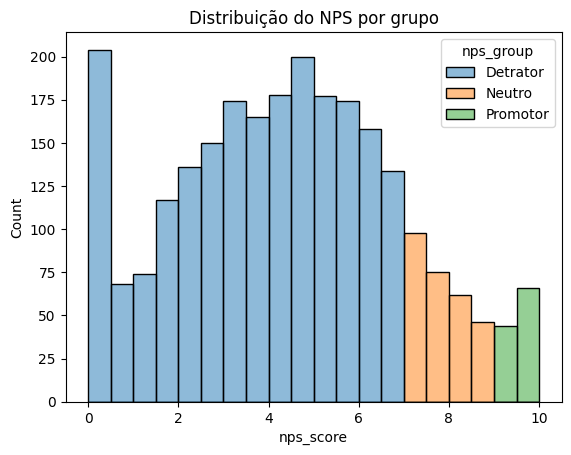

In [39]:
# Plotando um gráfico de histograma
sns.histplot(data=df_nps, x="nps_score", hue="nps_group")
plt.title("Distribuição do NPS por grupo")
plt.show()

##Que tipo de cliente tende a ter NPS mais alto ou mais baixo?
A análise sugere que clientes promotores tendem a estar associados a fidelização com maior probabilidade de recompra em 30 dias e maior tempo de relacionamento com a empresa. Esses clientes enfrentam menos problemas ao longo da compra, especialmente relacionado a área de logística.
Observa-se que a satisfação está fortemente relacionada com a qualidade da experiência ao longo da compra, impactada principalmente por fatores operacionais.

#Conclusão
Conclui-se que, com base nas informações obtidas nas análises realizadas, priorizar melhorias na experiência logística, especialmente na redução de atrasos, tende a reduzir o grau de insatisfação do cliente.

Além disso, é importante reforçar o atendimento ao cliente, reduzindo o tempo de resposta e a resolução de problemas.

Dessa forma, espera-se a melhoria do NPS e, consequentemente, o aumento da retenção, da recompra e do tempo de relacionamento dos clientes, contribuindo para o crescimento do negócio.